# Lab1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('movies_2026.csv', encoding='latin-1')

# Top 10 peliculas con presupuesto mas alto:

In [ ]:
df.sort_values(by='budget', ascending=False)[['title', 'budget']].head(10)

Top 10 peliculas con presupuesto mas alto:


,title,budget
10606,Pirates of the Caribbean: On Stranger Tides,380000000.0
14600,Avengers: Age of Ultron,365000000.0
15842,Avengers: Endgame,356000000.0
5907,Avatar: Fire and Ash,350000000.0
10053,Pirates of the Caribbean: At World's End,300000000.0
15843,Avengers: Infinity War,300000000.0
14843,Justice League,300000000.0
10497,Superman Returns,270000000.0
13681,Tangled,260000000.0
17024,The Lion King,260000000.0


# Top 10 peliculas con mayor ganancia:

In [ ]:
df.sort_values(by='revenue', ascending=False)[['title', 'revenue', 'actorsAmount']].head(10)

Top 10 peliculas con mayor ganancia:


,title,revenue,actorsAmount
13100,Avatar,2.847246e+09,37
15842,Avengers: Endgame,2.797801e+09,103
10197,Titanic,2.187464e+09,116
14837,Star Wars: The Force Awakens,2.068224e+09,188
15843,Avengers: Infinity War,2.046240e+09,65
8481,Zootopia 2,1.744338e+09,10
14804,Jurassic World,1.671713e+09,48
17024,The Lion King,1.667635e+09,20
18937,Spider-Man: No Way Home,1.631853e+09,59
13287,The Avengers,1.518816e+09,113


# Top pelicula con mayor cantidad de votos:

In [3]:
df.sort_values(by='voteCount', ascending=False)[['title', 'voteCount']].head(1)

,title,voteCount
13401,Inception,30788


# Top pelicula con mayor calificacion promedio:

In [4]:
df.sort_values(by='voteAvg', ascending=True)[['title', 'voteAvg']].head(1)

,title,voteAvg
26,Avant de Sortir,0.0


# Años donde mas peliculas se lanzaron

releaseYear
1902.0       1
1920.0       1
1921.0       1
1922.0       1
1925.0       2
          ... 
2020.0     531
2021.0     814
2022.0       7
2025.0    7351
2026.0    2537
Name: count, Length: 101, dtype: int64
Años donde mas peliculas se lanzaron: 2025.0


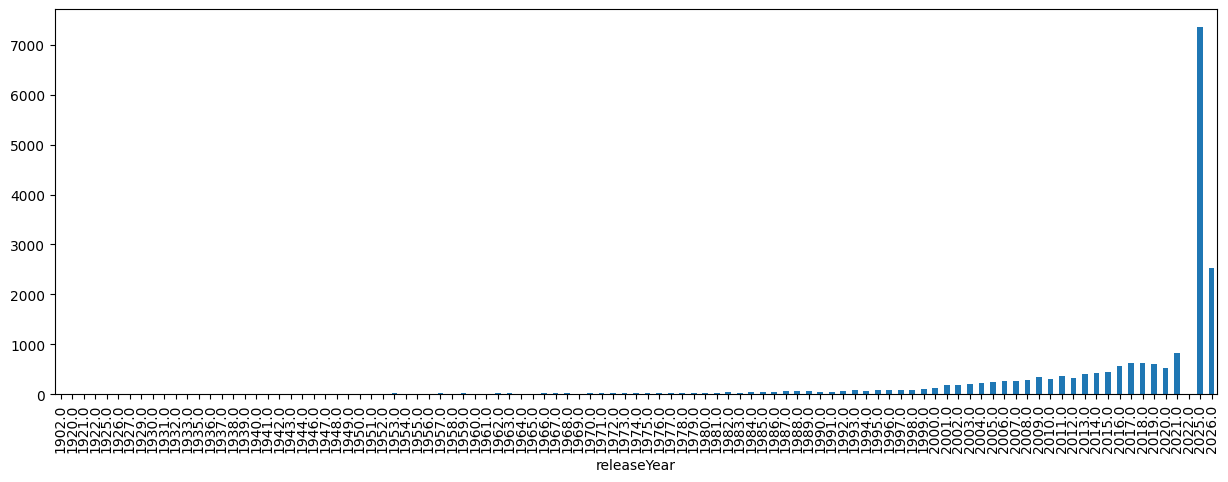

In [13]:
print(df['releaseYear'].value_counts().sort_index())
print("Años donde mas peliculas se lanzaron:", df['releaseYear'].value_counts().idxmax())

df['releaseYear'].value_counts().sort_index().plot(kind='bar', figsize=(15, 5))
plt.show()

# Genero de las 20 peliculas mas recientes:

Genero de las 20 peliculas mas recientes: Documentary
Genero predominante: Documentary


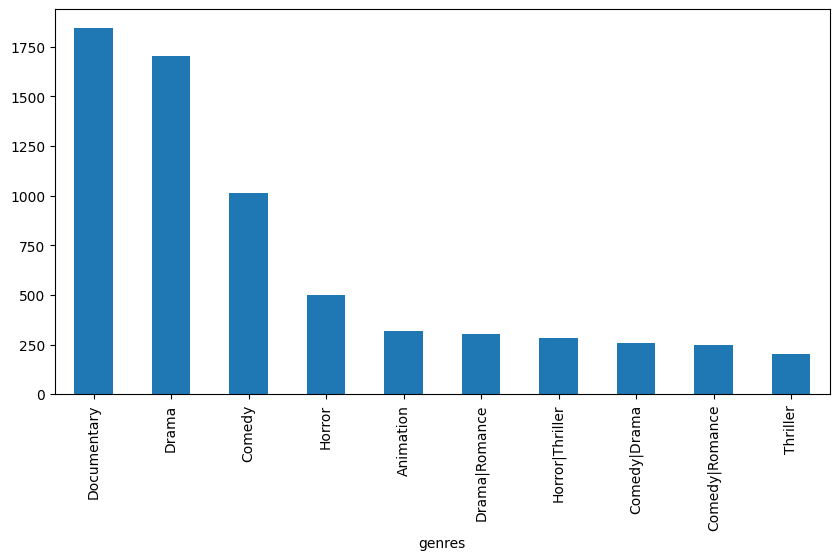

,title,runtime,genres
19234,How Ponyo was Born ~Hayao Miyazaki's Thought P...,750,Documentary
3275,Before the End,675,Action|Drama|Romance
8933,League of Legends Worlds25 - Finals in Cinema,420,NaN
15248,Crystal Lake Memories: The Complete History of...,400,Documentary
3582,In Search of Darkness: 1995-1999,384,Documentary|Horror


In [14]:
# 1. Genero de las 20 peliculas mas recientes
print("Genero de las 20 peliculas mas recientes:", df.sort_values(by='releaseDate', ascending=False).head(20)['genres'].mode()[0])

# 2. Genero predominante en el conjunto de datos
print("Genero predominante:", df['genres'].mode()[0])
df['genres'].value_counts().head(10).plot(kind='bar', figsize=(10, 5))
plt.show()

# 3. Genero de las peliculas mas largas (Mostrando las 5 mas largas)
df.sort_values(by='runtime', ascending=False)[['title', 'runtime', 'genres']].head(5)

# ¿Las películas de qué genero principal obtuvieron mayores ganancias?

--- Top 10 Géneros Principales por Ganancias (Promedio) ---


main_genre
Adventure          1.374463e+08
Action             8.018377e+07
Fantasy            6.273564e+07
Science Fiction    6.226071e+07
Family             5.772955e+07
War                5.310960e+07
Animation          3.694061e+07
Comedy             2.769929e+07
Crime              2.769499e+07
History            2.254319e+07
Name: revenue, dtype: float64

C:\Users\richi\AppData\Local\Temp\ipykernel_21840\301480377.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_revenue.head(10).values, y=genre_revenue.head(10).index, palette='viridis')


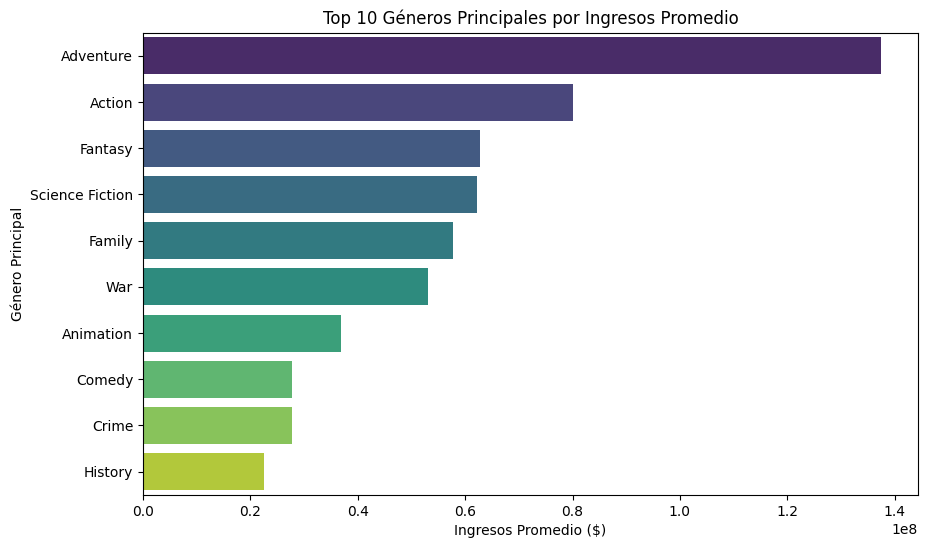

In [5]:
df_genres = df.copy()
df_genres = df_genres.dropna(subset=['genres'])
df_genres['main_genre'] = df_genres['genres'].astype(str).apply(lambda x: x.split('|')[0])
genre_revenue = df_genres.groupby('main_genre')['revenue'].mean().sort_values(ascending=False)
print("--- Top 10 Géneros Principales por Ganancias (Promedio) ---")
display(genre_revenue.head(10))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_revenue.head(10).values, y=genre_revenue.head(10).index, palette='viridis')
plt.title('Top 10 Géneros Principales por Ingresos Promedio')
plt.xlabel('Ingresos Promedio ($)')
plt.ylabel('Género Principal')
plt.show()

# ¿La cantidad de actores influye en los ingresos de las películas?¿se han hecho películas con más actores en los últimos años?

Total de películas: 19883
------------------------------
Revenue es 0: 14485 (72.85%)
Actors es 0:  2640 (13.28%)
Ambos son 0:  2633 (13.24%)

--- A. Todos los datos (Con Zoom) ---
Correlación: -0.0084


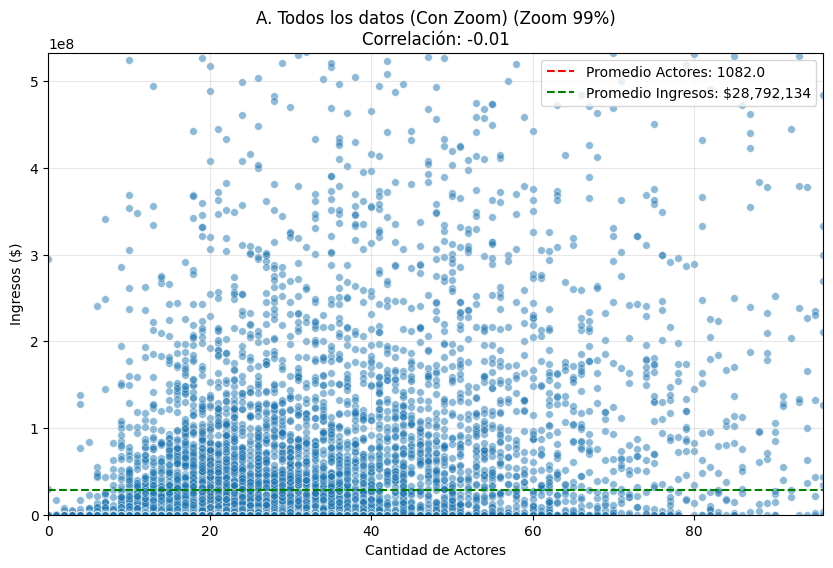


--- B. Sin ceros en Revenue (Con Zoom) ---
Correlación: -0.0017


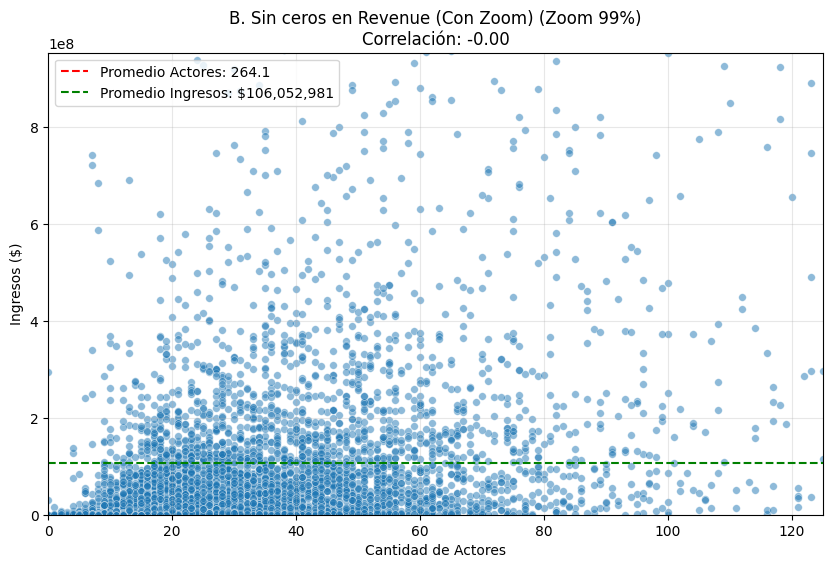


--- C. Sin ceros en Actores (Con Zoom) ---
Correlación: -0.0101


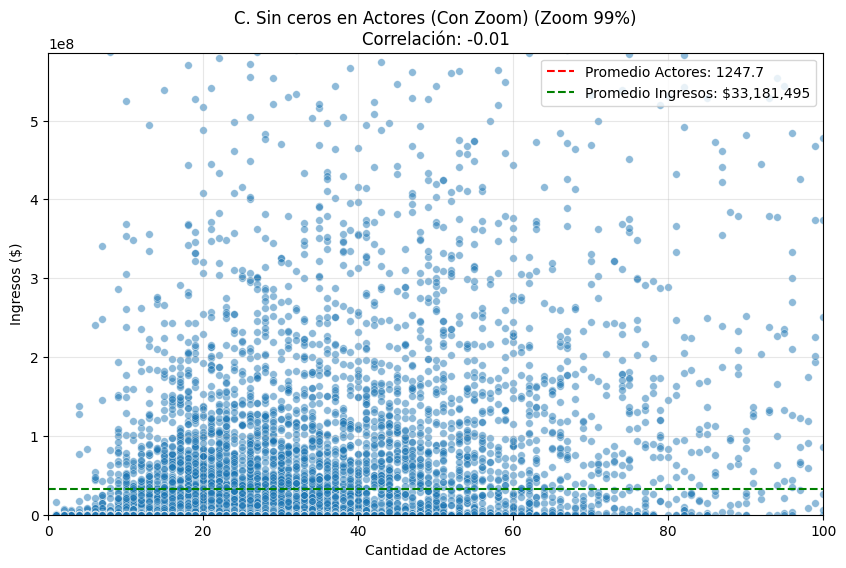


--- D. Sin ceros en Ambos (Con Zoom) ---
Correlación: -0.0017


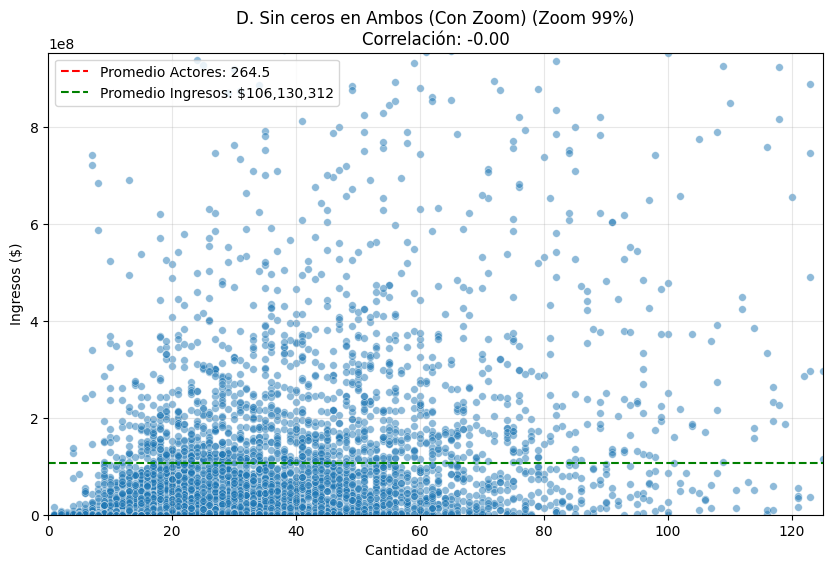

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

zeros_revenue = (df['revenue'] == 0).sum()
pct_revenue = (zeros_revenue / len(df)) * 100

zeros_actors = (df['actorsAmount'] == 0).sum()
pct_actors = (zeros_actors / len(df)) * 100

zeros_both = ((df['revenue'] == 0) & (df['actorsAmount'] == 0)).sum()
pct_both = (zeros_both / len(df)) * 100

print(f"Total de películas: {len(df)}")
print("-" * 30)
print(f"Revenue es 0: {zeros_revenue} ({pct_revenue:.2f}%)")
print(f"Actors es 0:  {zeros_actors} ({pct_actors:.2f}%)")
print(f"Ambos son 0:  {zeros_both} ({pct_both:.2f}%)")

def analizar_actores_ingresos_split(dataframe, titulo, zoom=False):
    corr = dataframe['actorsAmount'].corr(dataframe['revenue'])
    
    mean_actors = dataframe['actorsAmount'].mean()
    mean_revenue = dataframe['revenue'].mean()
    
    print(f"\n--- {titulo} ---")
    print(f"Correlación: {corr:.4f}")
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=dataframe, x='actorsAmount', y='revenue', alpha=0.5, s=30)
    
    plt.axvline(mean_actors, color='r', linestyle='--', label=f'Promedio Actores: {mean_actors:.1f}')
    plt.axhline(mean_revenue, color='g', linestyle='--', label=f'Promedio Ingresos: ${mean_revenue:,.0f}')
    
    if zoom:
        plt.xlim(0, dataframe['actorsAmount'].quantile(0.99)) 
        plt.ylim(0, dataframe['revenue'].quantile(0.99))     
        titulo += " (Zoom 99%)"
        
    plt.title(f"{titulo}\nCorrelación: {corr:.2f}")
    plt.xlabel("Cantidad de Actores")
    plt.ylabel("Ingresos ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

analizar_actores_ingresos_split(df, "A. Todos los datos (Con Zoom)", zoom=True)

df_rev = df[df['revenue'] > 0]
analizar_actores_ingresos_split(df_rev, "B. Sin ceros en Revenue (Con Zoom)", zoom=True)

df_act = df[df['actorsAmount'] > 0]
analizar_actores_ingresos_split(df_act, "C. Sin ceros en Actores (Con Zoom)", zoom=True)

df_clean = df[(df['revenue'] > 0) & (df['actorsAmount'] > 0)]
analizar_actores_ingresos_split(df_clean, "D. Sin ceros en Ambos (Con Zoom)", zoom=True)